Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Upload Dataset

In [3]:
df = pd.read_csv("customer_support_tickets.csv")

Display First 5 Rows

In [4]:
df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43.0,David Kim,5.0
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41.0,Elena Rodriguez,5.0
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7.0,Anya Sharma,5.0
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41.0,Anya Sharma,5.0
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40.0,David Kim,5.0


Dataset Shape

In [5]:
df.shape

(13838, 12)

Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13838 entries, 0 to 13837
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              13838 non-null  object 
 1   Customer_Name          13838 non-null  object 
 2   Customer_Email         13838 non-null  object 
 3   Ticket_Subject         13838 non-null  object 
 4   Ticket_Description     13837 non-null  object 
 5   Issue_Category         13837 non-null  object 
 6   Priority_Level         13837 non-null  object 
 7   Ticket_Channel         13837 non-null  object 
 8   Submission_Date        13837 non-null  object 
 9   Resolution_Time_Hours  13837 non-null  float64
 10  Assigned_Agent         13837 non-null  object 
 11  Satisfaction_Score     13837 non-null  float64
dtypes: float64(2), object(10)
memory usage: 1.3+ MB


Statistical Summary

In [7]:
df.describe(include="all")

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
count,13838,13838,13838,13838,13837,13837,13837,13837,13837,13837.000000,13837,13837.000000
unique,13838,12724,13589,10688,13837,5,4,3,731,NaN,5,NaN
top,TKT-113837,William Smith,vjohnson@example.org,Installation issue - Late,"Hi Support, I am not receiving the password re...",Technical,Low,Web Form,2025-10-07,NaN,Chloe Adams,NaN
freq,1,7,4,5,1,4080,5316,4662,32,NaN,2792,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.248753,NaN,3.720243
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.257421,NaN,1.288418
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,3.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.000000,NaN,5.000000


count → Total non-missing records.
unique → Number of different values.
top → Most common value.
freq → Number of times the most common value appears.

Check Missing Values

In [8]:
df.isnull().sum()

,0
Ticket_ID,0
Customer_Name,0
Customer_Email,0
Ticket_Subject,0
Ticket_Description,1
Issue_Category,1
Priority_Level,1
Ticket_Channel,1
Submission_Date,1
Resolution_Time_Hours,1


Display Column Names

In [9]:
df.columns

Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject',
       'Ticket_Description', 'Issue_Category', 'Priority_Level',
       'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours',
       'Assigned_Agent', 'Satisfaction_Score'],
      dtype='object')

Keep Required Columns

In [10]:
df = df[['Ticket_Description', 'Issue_Category']]

Display Dataset

In [12]:
df.head()

,Ticket_Description,Issue_Category
0,"Hi Support, Where is your headquarters located...",General Inquiry
1,"Hi Support, The application crashes every time...",Technical
2,"Hi Support, How do I upgrade to the Enterprise...",Account
3,"Hi Support, The dashboard is not loading any d...",Technical
4,"Hi Support, I have been trying to update my pa...",Billing


Check Class Distribution

In [11]:
df["Issue_Category"].value_counts()

,count
Issue_Category,
Technical,4080
Billing,3524
Account,2780
General Inquiry,2705
Fraud,748


Plot Category Distribution

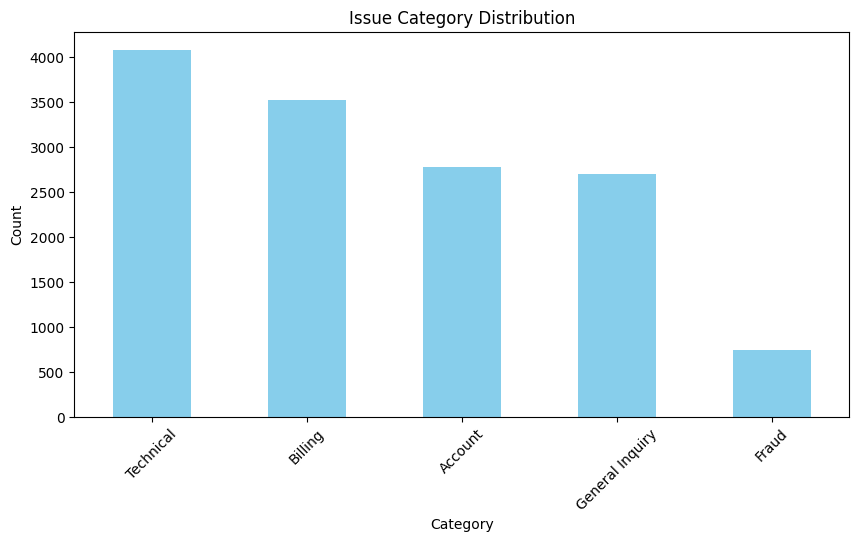

In [13]:
df["Issue_Category"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    color="skyblue"
)

plt.title("Issue Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Define Features and Target

In [14]:
X = df["Ticket_Description"]

y = df["Issue_Category"]

Check Missing Values

In [16]:
df[['Ticket_Description', 'Issue_Category']].isnull().sum()

,0
Ticket_Description,1
Issue_Category,1


Remove Missing Rows (

In [17]:
df = df.dropna(subset=['Ticket_Description', 'Issue_Category'])

In [18]:
df[['Ticket_Description', 'Issue_Category']].isnull().sum()

,0
Ticket_Description,0
Issue_Category,0


In [19]:
X = df["Ticket_Description"]

y = df["Issue_Category"]

Split Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Apply Hashing Vectorizer

In [21]:
vectorizer = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)

X_train_hash = vectorizer.transform(X_train)

X_test_hash = vectorizer.transform(X_test)

Train Model

In [22]:
model = MultinomialNB()

model.fit(X_train_hash, y_train)

MultinomialNB()

Predict Test Data

In [23]:
y_pred = model.predict(X_test_hash)

Accuracy

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9996387283236994


Accuracy Interpretation
-----------------------


| Metric     | Value      |
| ---------- | ---------- |
| Accuracy   | **0.9996** |
| Percentage | **99.96%** |
| Error Rate | **0.04%**  |


Classification Report

In [25]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       556
        Billing       1.00      1.00      1.00       705
          Fraud       1.00      0.99      1.00       150
General Inquiry       1.00      1.00      1.00       541
      Technical       1.00      1.00      1.00       816

       accuracy                           1.00      2768
      macro avg       1.00      1.00      1.00      2768
   weighted avg       1.00      1.00      1.00      2768



Confusion Matrix

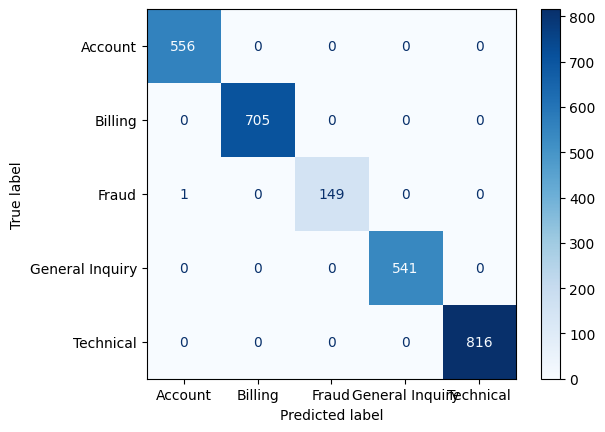

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.show()

| Category        | Total Test Tickets | Correct Predictions | Wrong Predictions |
| --------------- | -----------------: | ------------------: | ----------------: |
| Account         |                556 |                 556 |                 0 |
| Billing         |                705 |                 705 |                 0 |
| Fraud           |                150 |                 149 |                 1 |
| General Inquiry |                541 |                 541 |                 0 |
| Technical       |                816 |                 816 |                 0 |


Predict New Ticket

In [27]:
ticket = [
    "I forgot my password and cannot login."
]

ticket_hash = vectorizer.transform(ticket)

prediction = model.predict(ticket_hash)

print("Predicted Category :", prediction[0])

Predicted Category : Account


Try More Examples

In [28]:
ticket = [
    "Payment deducted twice from my bank account"
]

ticket_hash = vectorizer.transform(ticket)

print(model.predict(ticket_hash))

['Billing']


In [29]:
ticket = [
    "The application crashes whenever I open it"
]

ticket_hash = vectorizer.transform(ticket)

print(model.predict(ticket_hash))

['Technical']


In [30]:
ticket = [
    "Refund has not been credited to my account"
]

ticket_hash = vectorizer.transform(ticket)

print(model.predict(ticket_hash))

['Account']


Save Model

In [31]:
import joblib

joblib.dump(model, "customer_support_model.pkl")

['customer_support_model.pkl']

| Input                          | Process                                 | Output                            |
| ------------------------------ | --------------------------------------- | --------------------------------- |
| Trained Machine Learning Model | `joblib.dump()` saves the model to disk | `customer_support_model.pkl` file |

===========


Work flow
---------

| Step | Action                                     | Result                                        |
| ---- | ------------------------------------------ | --------------------------------------------- |
| 1    | Train the model                            | Model learns patterns from the training data  |
| 2    | Save the model using `joblib.dump()`       | Model is stored as a `.pkl` file              |
| 3    | Load the model later using `joblib.load()` | Model can make predictions without retraining |

===========
| Benefit            | Explanation                                                                      |
| ------------------ | -------------------------------------------------------------------------------- |
| Saves time         | No need to train the model every time the program runs.                          |
| Faster prediction  | Directly loads the trained model for inference.                                  |
| Easy deployment    | The saved model can be used in Streamlit, Flask, Django, or Hugging Face Spaces. |
| Reusable           | The same trained model can be shared or reused in other applications.            |
| Preserves training | Keeps all the learned parameters from the training process.                      |


Save Hashing Vectorizer

In [32]:
joblib.dump(vectorizer, "hashing_vectorizer.pkl")

['hashing_vectorizer.pkl']

Load Saved Model

In [33]:
model = joblib.load("customer_support_model.pkl")

vectorizer = joblib.load("hashing_vectorizer.pkl")

| Benefit                       | Explanation                                                             |
| ----------------------------- | ----------------------------------------------------------------------- |
| Consistent feature extraction | Ensures new text is converted into features exactly as during training. |
| Faster deployment             | No need to recreate the vectorizer each time the application starts.    |
| Required for prediction       | The saved model expects input transformed by the same vectorizer.       |
| Easy deployment               | Used in Streamlit, Flask, Django, or Hugging Face applications.         |
| Reusable                      | Can be shared and reused across different systems.                      |

==========

| Step | File Used                    | Action                                                                         |
| ---- | ---------------------------- | ------------------------------------------------------------------------------ |
| 1    | `hashing_vectorizer.pkl`     | Convert customer ticket text into numerical features                           |
| 2    | `customer_support_model.pkl` | Predict the issue category from those features                                 |
| 3    | Output                       | Display the predicted category (e.g., **Billing**, **Technical**, **Account**) |
